# Défi ÉquiAlgo : modèle corrigé et front de Pareto

Ce carnet présente notre solution d'atténuation. Le code de production est dans `model_corrige.py`.
Ce carnet l'utilise pour :

1. produire `predictions.csv` ;
2. tracer le **front de Pareto** en faisant varier l'intensité de la correction ;
3. comparer notre approche aux deux outils de fairlearn proposés dans les consignes
   (`ThresholdOptimizer` et `ExponentiatedGradient`).

Le diagnostic qui justifie la méthode est dans `audit_rapport.ipynb`.

## 1. La méthode en une page

Le comité applique la même règle à tout le monde (cote R, heures travaillées, revenu familial),
puis retire environ **1,4 point de cote R** aux candidats des régions éloignées. Il avantage aussi les
familles aisées.

1. **On apprend la règle du comité** avec une régression logistique. La région y figure explicitement
   sous la forme d'une variable `eloignee` (0 ou 1). Tout le biais régional se concentre ainsi dans
   un seul coefficient au lieu de se cacher dans les proxys.
2. **On n'utilise pas les proxys purs.** Le code postal et la distance ne sont pas donnés au modèle :
   à région égale, ils n'ont aucun effet sur la décision (audit, section 5).
3. **On décide de façon contrefactuelle.** Au moment de classer, on met `eloignee = 0` pour tout le
   monde et on donne à tous le même revenu (la médiane). Chaque dossier est jugé comme s'il venait
   d'un grand centre, sans avantage de fortune.
4. **On respecte l'enveloppe** en accordant la bourse aux 40 % de meilleurs scores, avec un seuil
   unique pour tous. Il n'y a aucun quota par région.

La région sert à **mesurer** le biais, jamais à **décider**.

Le réglage `intensite` (de 0 à 1) dit quelle part des deux biais on retire : 0 = règle du comité
telle quelle, 1 = biais entièrement retirés. C'est le bouton qu'on fait varier pour le front de
Pareto.

## 2. Prédictions finales

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, TruePositiveRateParity

from model_corrige import modele_comite, octroyer, preparer, score_sans_biais

BLEU, ORANGE, VERT, GRIS = '#2a78d6', '#eb6834', '#1baf7a', '#8a8984'
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e6e3', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.edgecolor': '#8a8984', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e', 'figure.dpi': 110,
})

demandes = preparer(pd.read_csv('data/donnees_demandes.csv'))
candidats = preparer(pd.read_csv('data/candidats_evaluation.csv'))

modele = modele_comite().fit(demandes, demandes['decision_octroi'])
decisions = octroyer(score_sans_biais(modele, candidats, demandes['log_revenu'].median()), 0.40)

soumission = pd.DataFrame({'id_candidat': candidats['id_candidat'], 'decision_octroi': decisions})
assert len(soumission) == 4000 and soumission['decision_octroi'].isin([0, 1]).all()
assert (soumission['id_candidat'] == candidats['id_candidat']).all()
assert 0.36 <= decisions.mean() <= 0.44, 'hors enveloppe'
soumission.to_csv('predictions.csv', index=False)

print(f"predictions.csv : {len(soumission)} lignes, taux d'octroi {decisions.mean():.1%}")
print(soumission.assign(groupe=np.where(candidats['eloignee'] == 1, 'regions eloignees', 'grands centres'))
      .groupby('groupe')['decision_octroi'].agg(candidats='size', bourses='sum', taux='mean').round(3))

predictions.csv : 4000 lignes, taux d'octroi 40.0%
                   candidats  bourses   taux
groupe                                      
grands centres          2372      945  0.398
regions eloignees       1628      655  0.402


## 3. Comment mesurer l'équité sans l'étalon ?

Le front de Pareto oppose une mesure d'**équité** à une mesure d'**utilité**. Les deux dépendent de
la référence choisie pour dire qui mérite la bourse. On les calcule donc contre **deux références**,
sur 30 % des dossiers historiques mis de côté (3 000 dossiers jamais vus à l'entraînement) :

- **Le comité** (`decision_octroi`) : c'est ce que voit l'institution aujourd'hui, biais compris.
- **Un pseudo-étalon de mérite** : la cote R + 0,146 × les heures travaillées, avec un peu de hasard
  (σ = 0,5 point de cote R), puis les 40 % meilleurs. Dans l'audit (section 9), cette hypothèse
  reproduit les deux chiffres connus : le 0,270 du jury et notre 94,73 % sur HxBuddy. On fait la
  moyenne sur 30 tirages du hasard.

**Équité** = écart d'égalité des chances : TPR des grands centres − TPR des régions éloignées. 0 est
l'idéal. Un écart négatif signifie qu'on favorise les régions.

In [2]:
train, test = train_test_split(demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi'])
eloigne_train = train['eloignee'].values
eloigne_test = test['eloignee'].values == 1
comite = test['decision_octroi'].values

rng = np.random.default_rng(42)
merite = test['cote_r_equivalent'].values + 0.146 * test['heures_travail_semaine'].values
pseudo_etalons = []
for _ in range(30):
    z = merite + rng.normal(0, 0.5, len(merite))
    pseudo_etalons.append((z >= np.quantile(z, 0.6)).astype(int))

def ecart_egalite_chances(reference, pred):
    tpr = lambda masque: pred[masque & (reference == 1)].mean()
    return tpr(~eloigne_test) - tpr(eloigne_test)

def mesurer(pred, methode, reglage):
    return {
        'methode': methode, 'reglage': reglage, "taux d'octroi": pred.mean(),
        'exactitude vs comite': (pred == comite).mean(),
        'ecart EC vs comite': ecart_egalite_chances(comite, pred),
        'exactitude vs merite': np.mean([(pred == r).mean() for r in pseudo_etalons]),
        'ecart EC vs merite': np.mean([ecart_egalite_chances(r, pred) for r in pseudo_etalons]),
    }

## 4. Le balayage

Trois familles de modèles, chacune avec plusieurs réglages de la contrainte :

| Méthode | Réglage balayé | Ce qu'elle fait |
|---|---|---|
| **Notre correction** | `intensite` de 0 à 1 | retire une part croissante de la pénalité régionale et de l'avantage de revenu |
| `ThresholdOptimizer` | `tol` de 0,10 à 0 | ajuste les seuils de la forêt en production, groupe par groupe, pour égaliser le TPR |
| `ExponentiatedGradient` | borne de 0,05 à 0,001 | réentraîne une régression logistique sous contrainte d'égalité des TPR |

Les deux outils de fairlearn reçoivent `decision_octroi` comme étiquette : c'est la seule
étiquette disponible. Ils ont accès aux mêmes colonnes que le modèle en production.

In [3]:
resultats = []

# Notre correction : on fait varier l'intensite.
modele_train = modele_comite().fit(train, train['decision_octroi'])
revenu_median = train['log_revenu'].median()
for intensite in np.linspace(0, 1, 11):
    pred = octroyer(score_sans_biais(modele_train, test, revenu_median, intensite), 0.40)
    resultats.append(mesurer(pred, 'Notre correction', round(intensite, 1)))

# Modele en production : la foret aleatoire du carnet de depart.
CATEGORIELLES = ['programme_etudes', 'region_administrative', 'code_postal_3']
def encoder(df):
    return pd.get_dummies(df.drop(columns=['id_candidat', 'decision_octroi', 'log_revenu', 'eloignee']),
                          columns=CATEGORIELLES, dtype=float)
X_train = encoder(train)
X_test = encoder(test).reindex(columns=X_train.columns, fill_value=0)
foret = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42).fit(X_train, train['decision_octroi'])
resultats.append(mesurer(foret.predict(X_test), 'Modele en production', None))

# ThresholdOptimizer sur la foret en production.
for tol in [0.10, 0.05, 0.02, 0.01, 0.0]:
    seuils = ThresholdOptimizer(estimator=foret, constraints='true_positive_rate_parity', prefit=True,
                                predict_method='predict_proba', tol=tol)
    seuils.fit(X_train, train['decision_octroi'], sensitive_features=eloigne_train)
    pred = seuils.predict(X_test, sensitive_features=eloigne_test.astype(int), random_state=0)
    resultats.append(mesurer(pred, 'ThresholdOptimizer', tol))

# ExponentiatedGradient avec une regression logistique.
for borne in [0.05, 0.02, 0.01, 0.005, 0.001]:
    contraint = ExponentiatedGradient(make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
                                      TruePositiveRateParity(difference_bound=borne),
                                      sample_weight_name='logisticregression__sample_weight')
    contraint.fit(X_train, train['decision_octroi'], sensitive_features=eloigne_train)
    resultats.append(mesurer(contraint.predict(X_test, random_state=0), 'ExponentiatedGradient', borne))

resultats = pd.DataFrame(resultats)
display(resultats.round(3))

,methode,reglage,taux d'octroi,exactitude vs comite,ecart EC vs comite,exactitude vs merite,ecart EC vs merite
0,Notre correction,0.000,0.400,0.885,0.097,0.877,0.319
1,Notre correction,0.100,0.400,0.883,0.080,0.886,0.292
2,Notre correction,0.200,0.400,0.884,0.054,0.894,0.263
3,Notre correction,0.300,0.400,0.881,0.004,0.908,0.214
4,Notre correction,0.400,0.400,0.882,-0.040,0.916,0.185
5,Notre correction,0.500,0.400,0.879,-0.067,0.924,0.157
6,Notre correction,0.600,0.400,0.875,-0.077,0.930,0.128
7,Notre correction,0.700,0.400,0.871,-0.108,0.937,0.095
8,Notre correction,0.800,0.400,0.865,-0.123,0.942,0.062
9,Notre correction,0.900,0.400,0.855,-0.150,0.946,0.023


## 5. Le front de Pareto

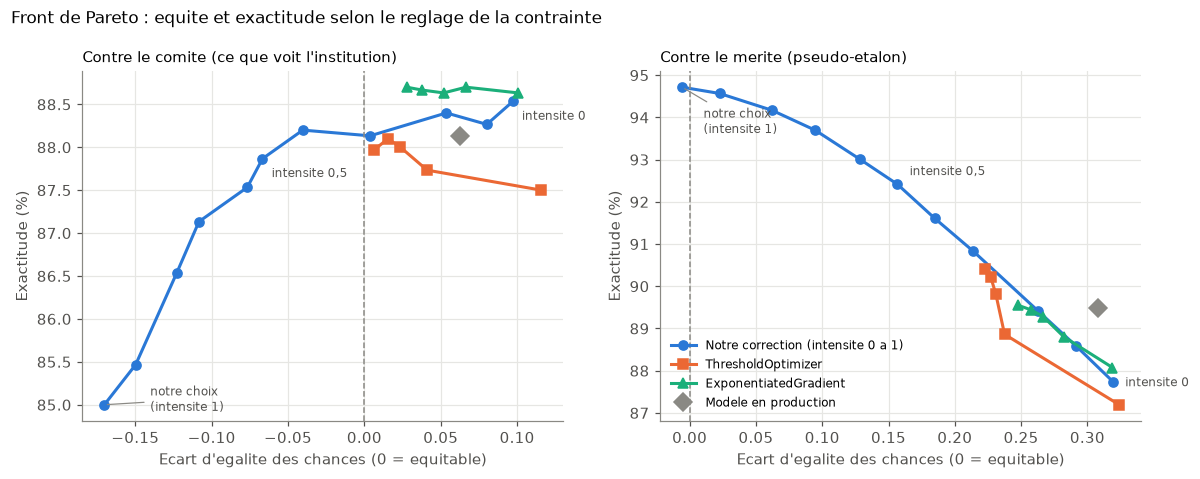

In [4]:
styles = {
    'Notre correction (intensite 0 a 1)': dict(color=BLEU, marker='o'),
    'ThresholdOptimizer': dict(color=ORANGE, marker='s'),
    'ExponentiatedGradient': dict(color=VERT, marker='^'),
}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=False)
panneaux = [('comite', "Contre le comite (ce que voit l'institution)"),
            ('merite', 'Contre le merite (pseudo-etalon)')]
for ax, (ref, titre) in zip(axes, panneaux):
    x, y = f'ecart EC vs {ref}', f'exactitude vs {ref}'
    for methode, style in styles.items():
        sous = resultats[resultats['methode'] == methode.split(' (')[0]]
        ax.plot(sous[x], sous[y] * 100, '-', lw=2, ms=6, label=methode, **style)
    prod = resultats[resultats['methode'] == 'Modele en production'].iloc[0]
    ax.plot(prod[x], prod[y] * 100, 'D', color=GRIS, ms=8, label='Modele en production')
    for intensite, decalage in [(0.0, (6, -12) if ref == 'comite' else (8, -3)),
                                (0.5, (6, -12) if ref == 'comite' else (8, 6))]:
        pt = resultats[(resultats['methode'] == 'Notre correction') & (resultats['reglage'] == intensite)].iloc[0]
        ax.annotate(f'intensite {intensite:g}'.replace('.', ','), (pt[x], pt[y] * 100), xytext=decalage,
                    textcoords='offset points', fontsize=8, color='#52514e',
                    ha='right' if decalage[0] < 0 else ('center' if decalage[0] == 0 else 'left'))
    choix = resultats[(resultats['methode'] == 'Notre correction') & (resultats['reglage'] == 1.0)].iloc[0]
    ax.annotate('notre choix\n(intensite 1)', (choix[x], choix[y] * 100), xytext=(30, -4) if ref == 'comite' else (14, -30),
                textcoords='offset points', fontsize=8, color='#52514e',
                arrowprops=dict(arrowstyle='-', color='#8a8984', lw=0.8))
    ax.axvline(0, color='#8a8984', lw=1, ls='--')
    ax.set_xlabel("Ecart d'egalite des chances (0 = equitable)")
    ax.set_ylabel('Exactitude (%)')
    ax.set_title(titre, loc='left', fontsize=10)
axes[1].legend(frameon=False, loc='lower left', fontsize=8)
fig.suptitle("Front de Pareto : equite et exactitude selon le reglage de la contrainte", x=0.01, ha='left', fontsize=11)
plt.tight_layout()
plt.savefig('front_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

### Lecture

**À gauche, contre le comité**, on voit le compromis classique : plus on corrige, plus on s'éloigne des
décisions passées (de 88,5 % à 85,0 % d'exactitude). Les deux outils de fairlearn réduisent fortement
leur propre écart (0,006 pour `ThresholdOptimizer`, 0,028 pour `ExponentiatedGradient`) sans perdre
d'exactitude. C'est rassurant en apparence.

**À droite, contre le mérite**, le tableau s'inverse :

- **Notre correction n'a pas de compromis.** Chaque pas d'intensité améliore *à la fois* l'équité et
  l'exactitude, de 88 % à environ 95 %. La courbe monte vers le coin idéal (écart 0, exactitude
  maximale). Le point final domine tous les autres modèles.
- **Les outils de fairlearn ferment le mauvais écart.** Ils égalisent le TPR mesuré contre
  `decision_octroi`, une étiquette biaisée. Contre le mérite, même à leur réglage le plus strict, leur
  écart reste de 0,22 à 0,25, à peine moins que le modèle en production (0,31). C'est le piège annoncé dans le carnet de départ : *« on vient
  de vérifier que le modèle reproduit fidèlement le comité »*.

**Pourquoi l'intensité 1.** C'est le seul réglage qui ramène l'écart près de 0 contre le mérite, et
c'est aussi le plus exact. Une intensité partielle reviendrait à garder volontairement une partie
d'une pénalité qu'aucun critère légitime ne justifie.

**Le compromis de gauche n'en est pas un.** Perdre 3,5 points d'exactitude contre le comité veut dire
qu'on cesse de reproduire ses erreurs. Si `decision_octroi` est biaisée, le meilleur modèle n'est pas
celui qui la prédit le mieux.

## 6. Robustesse au choix du pseudo-étalon

La conclusion ne doit pas dépendre d'un réglage précis du pseudo-étalon. On fait varier le hasard
(σ) et le poids des heures travaillées, puis on compare le modèle en production à notre correction.

In [5]:
pred_prod = foret.predict(X_test)
pred_nous = octroyer(score_sans_biais(modele_train, test, revenu_median), 0.40)
lignes = []
for poids in [0.0, 0.1, 0.146, 0.2]:
    for sigma in [0.25, 0.5, 1.0]:
        refs = []
        for _ in range(30):
            z = test['cote_r_equivalent'].values + poids * test['heures_travail_semaine'].values + rng.normal(0, sigma, len(test))
            refs.append((z >= np.quantile(z, 0.6)).astype(int))
        lignes.append({'poids heures': poids, 'sigma': sigma,
                       'ecart EC production': np.mean([ecart_egalite_chances(r, pred_prod) for r in refs]),
                       'ecart EC corrige': np.mean([ecart_egalite_chances(r, pred_nous) for r in refs]),
                       'exactitude production': np.mean([(pred_prod == r).mean() for r in refs]),
                       'exactitude corrige': np.mean([(pred_nous == r).mean() for r in refs])})
display(pd.DataFrame(lignes).round(3))

,poids heures,sigma,ecart EC production,ecart EC corrige,exactitude production,exactitude corrige
0,0.000,0.25,0.233,-0.067,0.938,0.937
1,0.000,0.50,0.212,-0.072,0.923,0.924
2,0.000,1.00,0.199,-0.070,0.886,0.888
3,0.100,0.25,0.293,-0.027,0.917,0.967
4,0.100,0.50,0.279,-0.029,0.908,0.945
5,0.100,1.00,0.256,-0.032,0.878,0.900
6,0.146,0.25,0.315,-0.010,0.905,0.971
7,0.146,0.50,0.306,-0.005,0.897,0.948
8,0.146,1.00,0.283,-0.007,0.870,0.901
9,0.200,0.25,0.340,0.020,0.889,0.965


Quel que soit le réglage, notre correction réduit l'écart d'égalité des chances d'environ deux tiers
ou plus, et elle est au moins aussi exacte que le modèle en production. Le cas le moins favorable est
un mérite fondé sur la seule cote R (poids des heures = 0) : l'exactitude est alors égale (environ 93,7 %
des deux côtés), et notre modèle favorise légèrement les régions (écart de −0,07 contre +0,21 en
production). Le réglage du pseudo-étalon change l'ampleur du gain, pas la conclusion.